# Rating Prediction — Proyecto Completo de Sistemas de Recomendación

**Objetivo:** Predecir la valoración (1–5 estrellas) que un usuario dará a un negocio, usando un subconjunto del dataset de Yelp.  
**Métrica principal:** MAE (Mean Absolute Error).  
**Mejor resultado en leaderboard:** `0.6528` (meta-LightGBM hybrid v1).

---

Este notebook resume la evolución completa del proyecto, desde los modelos base de **filtrado colaborativo** hasta la arquitectura deep end-to-end de **content-based routing**. Cada sección carga artefactos reales del repositorio o los construye desde cero, y está acompañada de comentarios que explican las decisiones de diseño, los experimentos realizados y las conclusiones obtenidas.

## Tabla de contenidos

1. [Configuración del entorno](#1-configuración-del-entorno)
2. [Análisis Exploratorio de Datos (EDA)](#2-análisis-exploratorio-de-datos-eda)
   - 2.1 [Dataset: carga y exploración](#21-dataset-carga-y-exploración)
   - 2.2 [Auditoría de leakage y cold start](#22-auditoría-de-leakage-y-cold-start)
   - 2.3 [Representación de negocios](#23-representación-de-negocios)
   - 2.4 [Representación manual de usuarios](#24-representación-manual-de-usuarios)
   - 2.5 [Red social: ¿se parecen los amigos?](#25-red-social-se-parecen-los-amigos)
3. [Filtrado Colaborativo — modelos baseline](#3-filtrado-colaborativo-modelos-baseline)
4. [LightGBM tabular: raw_core baseline](#4-lightgbm-tabular-raw_core-baseline)
5. [Router con arquetipos de cold start](#5-router-con-arquetipos-de-cold-start)
6. [Deep User Embeddings — arquitectura y export](#6-deep-user-embeddings-arquitectura-y-export)
7. [Router prefix-deep para usuarios conocidos intermedios](#7-router-prefix-deep-para-usuarios-conocidos-intermedios)
8. [Known-User Deep Router (end-to-end neural)](#8-known-user-deep-router-end-to-end-neural)
9. [Two-Tower Router — experimento y descarte](#9-two-tower-router-experimento-y-descarte)
10. [Meta-stacking: combinación CF + CB](#10-meta-stacking-combinación-cf-cb)
11. [Mejora del cold model: ciclo v2–v6](#11-mejora-del-cold-model-ciclo-v2v6)
12. [Mejora en Deep router: MAE loss fix](#12-mejora-en-deep-router-mae-loss-fix)
13. [Comparativa global de modelos](#13-comparativa-global-de-modelos)
14. [Conclusiones y trabajo futuro](#14-conclusiones-y-trabajo-futuro)


## 1. Configuración del entorno

Importamos las librerías del proyecto. Todo el código de utilidades está en `content-based/utils/` y los modelos en `content-based/model/`. El notebook asume que se ejecuta desde el directorio `content-based/`.

In [4]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

# Asegurar que el directorio content-based está en el path
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Módulos propios del proyecto
from utils.io import load_users, load_businesses, load_train_reviews, load_test_reviews, canonicalize_reviews
from utils.split import random_train_validation_split, temporal_train_validation_split, cold_start_breakdown
from utils.audit import build_user_train_aggregates, build_business_train_aggregates
from utils.lgbm_raw_features import history_band_from_count

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


## 2. Análisis Exploratorio de Datos (EDA)

Esta sección agrupa todo el análisis exploratorio del dataset: estadísticas básicas, auditoría de leakage y cold start, representación de contenido de negocios y usuarios, y el análisis de la red social de amigos (homofilia de gustos).


### 2.1. Dataset: carga y exploración

El dataset es un subconjunto de **Yelp** con 4 tablas:

| Tabla | Descripción |
|---|---|
| `usuarios.csv` | Perfiles de usuario (review count, promedio de estrellas, amigos, élite, etc.) |
| `negocios.csv` | Metadatos de negocio (categorías, atributos, horas, ciudad, coordenadas) |
| `train_reviews.csv` | Reviews de entrenamiento con rating (1–5 estrellas) |
| `test_reviews.csv` | Reviews de test (sin rating, para predicción competitiva) |

El dataset es **muy disperso**: la mayoría de usuarios tienen pocas reviews, lo que genera un fuerte problema de **cold start** en la evaluación.

In [5]:
users_df = load_users()
businesses_df = load_businesses()
train_reviews_df = load_train_reviews()
test_reviews_df = load_test_reviews()

print(f"Usuarios:          {len(users_df):>8,}")
print(f"Negocios:          {len(businesses_df):>8,}")
print(f"Reviews de train:  {len(train_reviews_df):>8,}")
print(f"Reviews de test:   {len(test_reviews_df):>8,}")

Usuarios:           699,619
Negocios:            30,069
Reviews de train:   967,784
Reviews de test:    414,765


Distribución de ratings en train:
stars
1.0000    148134
2.0000     73595
3.0000     93676
4.0000    199493
5.0000    452886
Name: count, dtype: int64

Media global: 3.7599
Std global:   1.4795


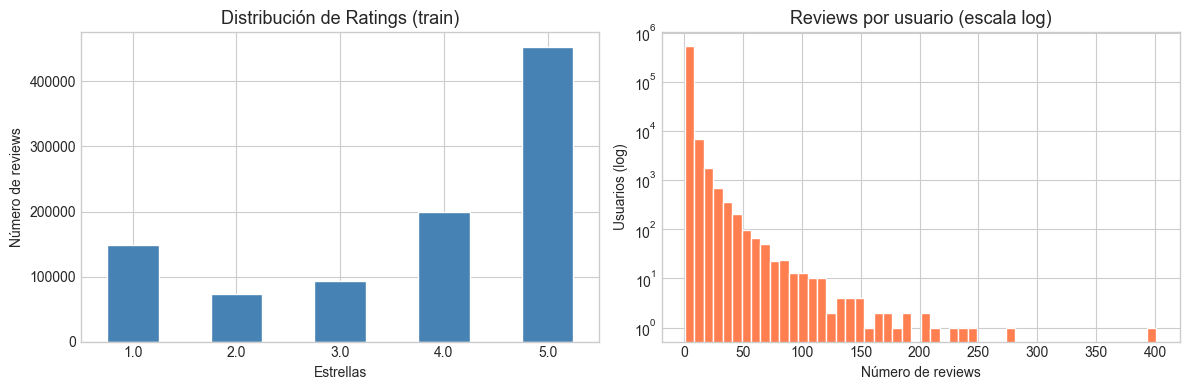


Mediana de reviews por usuario: 1
Usuarios con <= 5 reviews: 522,110 (96.3%)


In [6]:
# Estadísticas básicas de los ratings de entrenamiento
print("Distribución de ratings en train:")
print(train_reviews_df["stars"].value_counts().sort_index())
print(f"\nMedia global: {train_reviews_df['stars'].mean():.4f}")
print(f"Std global:   {train_reviews_df['stars'].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de ratings
train_reviews_df["stars"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Distribución de Ratings (train)", fontsize=13)
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Número de reviews")
axes[0].tick_params(axis="x", rotation=0)

# Reviews por usuario (histograma log)
review_counts = train_reviews_df.groupby("user_id").size()
axes[1].hist(review_counts, bins=50, color="coral", edgecolor="white", log=True)
axes[1].set_title("Reviews por usuario (escala log)", fontsize=13)
axes[1].set_xlabel("Número de reviews")
axes[1].set_ylabel("Usuarios (log)")

plt.tight_layout()
plt.show()

print(f"\nMediana de reviews por usuario: {review_counts.median():.0f}")
print(f"Usuarios con <= 5 reviews: {(review_counts <= 5).sum():,} ({(review_counts <= 5).mean()*100:.1f}%)")

### 2.2. Auditoría de leakage y cold start

Antes de entrenar cualquier modelo es crítico entender:

1. **Cold start**: ¿qué porcentaje de reviews de test pertenecen a usuarios o negocios no vistos en train?
2. **Leakage**: ¿qué features de usuario/negocio contienen información que sólo estaría disponible en el momento de la predicción?

### Política de leakage del proyecto

Separar siempre **metadata segura** (estructura del negocio: categorías, horarios, atributos) de **agregados de comportamiento** (promedio de estrellas calculado sobre todas las reviews históricas del usuario).

### Bandas de historial de usuario

El proyecto organiza a los usuarios en bandas según su número de reviews en train:

| Banda | Reviews | Interpretación |
|---|---|---|
| `0` | 0 | Cold start (usuario nuevo) |
| `1` | 1 | Muy poco historial |
| `2-5` | 2–5 | Historial corto |
| `6-20` | 6–20 | Historial medio |
| `>20` | >20 | Usuario activo |

=== Cold Start Analysis (train vs test) ===
  total_rows                      414,765  
  both_known                      244,812  (59.0%)
  new_user_known_item             169,927  (41.0%)
  known_user_new_item                  16  (0.0%)
  both_new                             10  (0.0%)
  both_known_pct                 0.5902426675346281  (0.0%)
  new_user_known_item_pct        0.4096946463660145  (0.0%)
  known_user_new_item_pct        3.857606114305691e-05  (0.0%)
  both_new_pct                   2.411003821441057e-05  (0.0%)


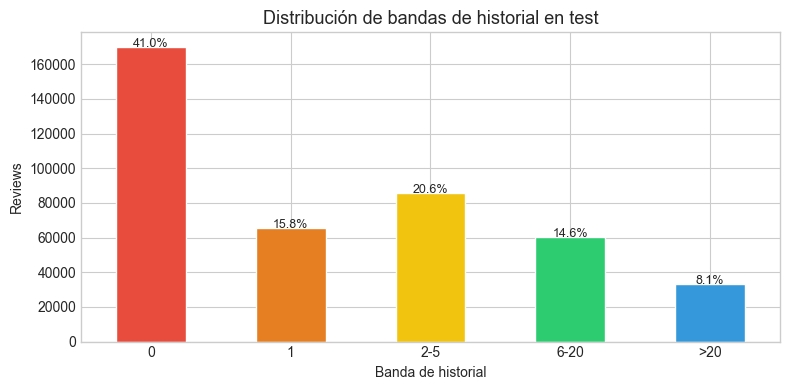


Banda 0 (cold users): 169,937 reviews = 41.0% del test


In [9]:
from utils.split import cold_start_breakdown

# Análisis cold start: train vs test oficial
train_can = canonicalize_reviews(train_reviews_df)
test_can = canonicalize_reviews(test_reviews_df)

cold = cold_start_breakdown(train_can, test_can)
print("=== Cold Start Analysis (train vs test) ===")
for k, v in cold.items():
    pct = f"({v / cold['total_rows'] * 100:.1f}%)" if k != "total_rows" else ""
    print(f"  {k:<30} {v:>8,}  {pct}")

# Distribución de bandas en test (simulando con historial de train)
user_counts = train_can.groupby("user").size().reset_index(name="review_count")
test_with_history = test_can.merge(user_counts, on="user", how="left").fillna({"review_count": 0})
test_with_history["history_band"] = test_with_history["review_count"].apply(history_band_from_count)

band_dist = test_with_history["history_band"].value_counts().reindex(
    ["0", "1", "2-5", "6-20", ">20"], fill_value=0
)

fig, ax = plt.subplots(figsize=(8, 4))
band_dist.plot(kind="bar", ax=ax, color=["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#3498db"],
               edgecolor="white")
ax.set_title("Distribución de bandas de historial en test", fontsize=13)
ax.set_xlabel("Banda de historial")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(band_dist):
    ax.text(i, v + 50, f"{v/len(test_with_history)*100:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nBanda 0 (cold users): {band_dist['0']:,} reviews = {band_dist['0']/len(test_with_history)*100:.1f}% del test")

### 2.3. Representación de negocios

La **representación estructurada de negocios** es la base de toda la rama content-based. Se construye en `utils/business_representation.py` y `utils/business_features.py`.

### Bloques de features

| Bloque | Contenido | Tipo |
|---|---|---|
| `geo` | Latitud, longitud, ciudad, estado, código postal | Numérico + categórico |
| `categories` | One-hot de categorías (familia principal, subcategorías) | Binario |
| `attributes` | Atributos del negocio (ruido, parking, tipo de comida, etc.) | Binario + categórico |
| `hours` | Minutos abiertos/semana, días activos, noches, fines de semana | Numérico |
| `priors` | Priors de rating calculados solo desde `train_reviews` | Numérico |

### Matrices expuestas

- `content_matrix`: sólo features estructurales (sin priors)
- `prior_matrix`: priors calculados desde train
- `full_matrix`: unión de ambas

> **Decisión de diseño**: Los priors de rating del negocio se calculan exclusivamente desde `train_reviews`, nunca desde los metadatos de Yelp all-time, para evitar leakage en la evaluacion.

Negocio de ejemplo: Rudy's Pub & Grill
Categorías parsed: ['Nightlife', 'American (Traditional)', 'Pubs', 'Restaurants', 'Bars', 'American (New)', 'Sports Bars']


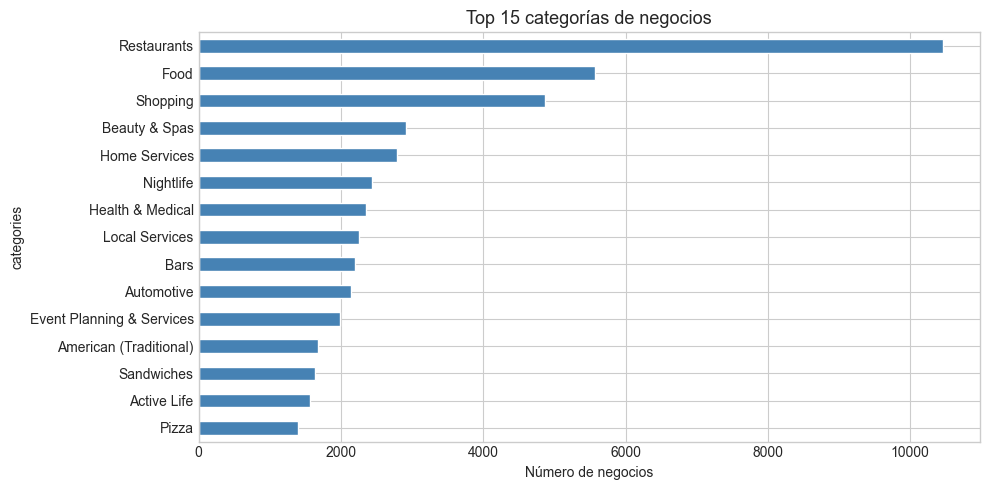


Total categorías únicas: 1,201


In [17]:
from utils.business_features import parse_categories, parse_attributes, extract_hours_features

# Mostrar ejemplo de parseo de categorías
sample_biz = businesses_df.dropna(subset=["categories"]).iloc[55]
print("Negocio de ejemplo:", sample_biz.get("name", sample_biz.get("business_id")))
parsed_cats = parse_categories(sample_biz["categories"])
print("Categorías parsed:", parsed_cats)

# Distribución de categorías principales
all_categories = businesses_df["categories"].dropna().str.split(", ").explode()
top_cats = all_categories.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_cats.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 categorías de negocios", fontsize=13)
ax.set_xlabel("Número de negocios")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal categorías únicas: {all_categories.nunique():,}")

### 2.4. Representación manual de usuarios

La representación manual de usuario (`utils/user_representation.py`) agrega el perfil del usuario desde los negocios que ha valorado previamente.

### Modos de agregación

| Modo | Descripción |
|---|---|
| `mean` | Media simple de los vectores de negocio valorados |
| `rating` | Media ponderada por el rating dado a cada negocio |
| `centered` | Media ponderada por `(rating - media_global)` — enfatiza preferencias extremas |
| `recency` | Media ponderada por la recencia de la review |

### Outputs

- `user_profile_features`: perfil basado en el contenido de los negocios
- `user_metadata_features`: metadata segura del propio perfil de usuario (review count, tenure, etc.)
- `user_full_features`: unión

### Limitaciones

- Para usuarios cold (band `0`), no hay historial, por lo que no se puede construir un perfil agregado.  
  → Se resuelve con **arquetipos de usuario** en el cold model.
- La representación manual no captura interacciones entre usuario y negocio candidato.  
  → Se resuelve con la **arquitectura deep end-to-end**.

In [ ]:
from utils.audit import build_user_train_aggregates

# Estadísticas de historial de usuarios en train
user_aggs = build_user_train_aggregates(train_reviews_df)

print(f"Usuarios con reviews en train: {len(user_aggs):,}")
print(f"\nEstadísticas de review_count en train:")
print(user_aggs["train_review_count"].describe().to_frame().T.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución del rating promedio por usuario
axes[0].hist(user_aggs["train_average_stars"].dropna(), bins=40, color="mediumseagreen", edgecolor="white")
axes[0].set_title("Distribución: rating promedio por usuario (train)", fontsize=12)
axes[0].set_xlabel("Promedio de estrellas")
axes[0].set_ylabel("Usuarios")

# Distribución de review count (top 95%)
q95 = user_aggs["train_review_count"].quantile(0.95)
axes[1].hist(user_aggs.loc[user_aggs["train_review_count"] <= q95, "train_review_count"],
             bins=40, color="mediumpurple", edgecolor="white")
axes[1].set_title(f"Reviews por usuario en train (≤ p95 = {q95:.0f})", fontsize=12)
axes[1].set_xlabel("Reviews en train")
axes[1].set_ylabel("Usuarios")

plt.tight_layout()
plt.show()

### 2.5. Red social: ¿se parecen los amigos?

Una hipótesis natural en sistemas de recomendación es la **homofilia**: los usuarios tienden a tener gustos similares a sus amigos. Si esto se cumple en el dataset de Yelp, la red social podría ser una señal predictiva útil.

Este análisis responde tres preguntas:

1. **Estructura de la red**: ¿cómo es la distribución de grado? ¿hay usuarios muy conectados?
2. **Homofilia en ratings**: ¿los amigos dan ratings más similares entre sí que usuarios aleatorios con perfil parecido?
3. **Homofilia en embeddings** (si existen artefactos): ¿los embeddings deep capturan esta similitud mejor que la representación manual?

> El código de análisis de similitud en el espacio de embeddings vive en `analysis/embeddings_report.py` → `build_friend_similarity_analysis()`.

In [18]:
from analysis.embeddings_report import parse_friends

# ── 1. Estructura de la red de amigos ────────────────────────────────────────
users_with_friends = users_df[["user_id", "friends", "average_stars", "review_count"]].copy()
users_with_friends["friend_list"] = users_with_friends["friends"].apply(parse_friends)
users_with_friends["degree"] = users_with_friends["friend_list"].apply(len)

valid_user_ids = set(users_df["user_id"].astype(str))

# Filtrar a amigos que realmente están en el dataset
users_with_friends["degree_in_dataset"] = users_with_friends["friend_list"].apply(
    lambda fl: sum(1 for f in fl if f in valid_user_ids)
)

total_users = len(users_with_friends)
users_with_any_friend = (users_with_friends["degree_in_dataset"] > 0).sum()
print(f"Usuarios totales:                  {total_users:,}")
print(f"Usuarios con ≥1 amigo en dataset:  {users_with_any_friend:,}  ({users_with_any_friend/total_users*100:.1f}%)")
print(f"Grado medio (en dataset):          {users_with_friends['degree_in_dataset'].mean():.2f}")
print(f"Grado mediano:                     {users_with_friends['degree_in_dataset'].median():.0f}")
print(f"Grado p90:                         {users_with_friends['degree_in_dataset'].quantile(0.90):.0f}")
print(f"Grado máximo:                      {users_with_friends['degree_in_dataset'].max()}")
print(f"Aristas dirigidas estimadas:       {users_with_friends['degree_in_dataset'].sum():,}")

Usuarios totales:                  699,619
Usuarios con ≥1 amigo en dataset:  319,356  (45.6%)
Grado medio (en dataset):          6.42
Grado mediano:                     0
Grado p90:                         12
Grado máximo:                      5215
Aristas dirigidas estimadas:       4,489,738


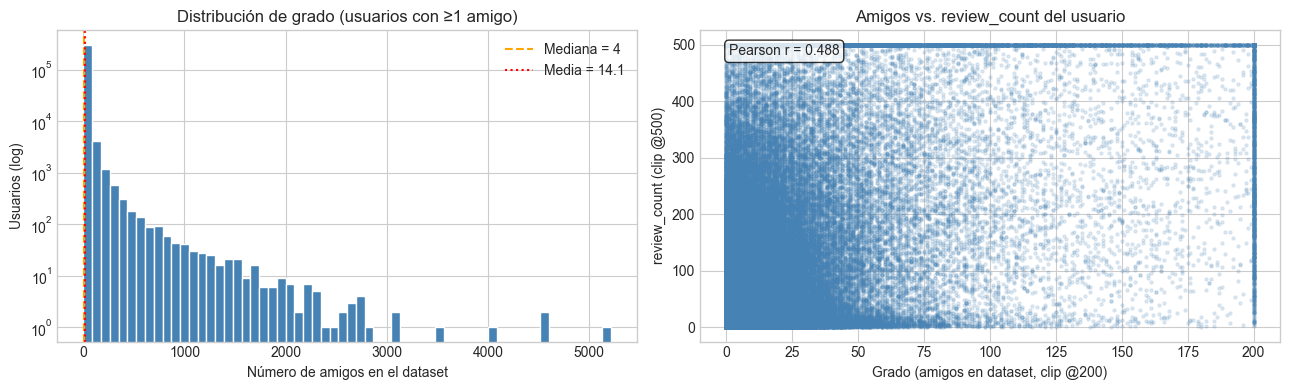


Correlación Pearson (degree, review_count): 0.4879
Los usuarios más activos tienden a tener más amigos en la plataforma.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de grado (usuarios con amigos, escala log)
connected = users_with_friends[users_with_friends["degree_in_dataset"] > 0]["degree_in_dataset"]
axes[0].hist(connected, bins=60, color="steelblue", edgecolor="white", log=True)
axes[0].set_title("Distribución de grado (usuarios con ≥1 amigo)", fontsize=12)
axes[0].set_xlabel("Número de amigos en el dataset")
axes[0].set_ylabel("Usuarios (log)")
axes[0].axvline(x=connected.median(), color="orange", linestyle="--", label=f"Mediana = {connected.median():.0f}")
axes[0].axvline(x=connected.mean(), color="red", linestyle=":", label=f"Media = {connected.mean():.1f}")
axes[0].legend()

# Relación entre degree e intensidad de reseñas
axes[1].scatter(
    users_with_friends["degree_in_dataset"].clip(upper=200),
    users_with_friends["review_count"].clip(upper=500),
    alpha=0.15, s=5, color="steelblue"
)
axes[1].set_title("Amigos vs. review_count del usuario", fontsize=12)
axes[1].set_xlabel("Grado (amigos en dataset, clip @200)")
axes[1].set_ylabel("review_count (clip @500)")

# Correlación
corr = users_with_friends[["degree_in_dataset", "review_count"]].corr().iloc[0, 1]
axes[1].annotate(f"Pearson r = {corr:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\nCorrelación Pearson (degree, review_count): {corr:.4f}")
print("Los usuarios más activos tienden a tener más amigos en la plataforma.")

### Homofilia en ratings

Comprobamos si los pares **amigo–amigo** tienen un `average_stars` más parecido que pares **usuario–usuario aleatorio** con perfil similar (mismo cuartil de `review_count`).

**Hipótesis nula**: los amigos no tienen gustos más similares que no-amigos. Si hay homofilia, el MAE de `average_stars` entre amigos debería ser menor.

In [ ]:
rng = np.random.default_rng(42)

# Lookup rápido: user_id → average_stars
stars_lookup = users_df.set_index("user_id")["average_stars"].dropna()

# Cuartiles de review_count para el matching de negativos
rc_quantiles = users_df["review_count"].quantile([0.25, 0.5, 0.75]).values
def rc_bucket(rc):
    if rc <= rc_quantiles[0]: return 0
    if rc <= rc_quantiles[1]: return 1
    if rc <= rc_quantiles[2]: return 2
    return 3

users_df["rc_bucket"] = users_df["review_count"].apply(rc_bucket)
bucket_pools = {b: users_df.loc[users_df["rc_bucket"] == b, "user_id"].values
                for b in range(4)}

# Muestrear pares amigo-amigo (positivos) y usuario-aleatorio (negativos)
MAX_ANCHORS = 3000
MAX_PAIRS_PER_ANCHOR = 3

positive_pairs = []  # (stars_anchor, stars_friend)
negative_pairs = []  # (stars_anchor, stars_random)

anchors_with_friends = users_with_friends[
    users_with_friends["degree_in_dataset"] > 0
].sample(n=min(MAX_ANCHORS, (users_with_friends["degree_in_dataset"] > 0).sum()), random_state=42)

for _, row in anchors_with_friends.iterrows():
    anchor_id = row["user_id"]
    if anchor_id not in stars_lookup:
        continue
    anchor_stars = stars_lookup[anchor_id]
    valid_friends = [f for f in row["friend_list"] if f in valid_user_ids and f in stars_lookup]
    if not valid_friends:
        continue
    chosen = valid_friends if len(valid_friends) <= MAX_PAIRS_PER_ANCHOR else \
             rng.choice(valid_friends, size=MAX_PAIRS_PER_ANCHOR, replace=False).tolist()
    anchor_bucket = row["rc_bucket"] if "rc_bucket" in row.index else 1
    pool = bucket_pools.get(anchor_bucket, bucket_pools[0])
    friend_set = set(valid_friends) | {anchor_id}
    for friend_id in chosen:
        friend_stars = stars_lookup[friend_id]
        positive_pairs.append((anchor_stars, friend_stars))
        # Negativo: usuario aleatorio del mismo cuartil que no sea amigo
        candidates = pool[pool != anchor_id]
        candidates = candidates[~np.isin(candidates, list(friend_set))]
        if len(candidates) == 0:
            continue
        neg_id = rng.choice(candidates)
        if neg_id in stars_lookup:
            negative_pairs.append((anchor_stars, float(stars_lookup[neg_id])))

pos_arr = np.array(positive_pairs)
neg_arr = np.array(negative_pairs)

mae_friends  = np.mean(np.abs(pos_arr[:, 0] - pos_arr[:, 1]))
mae_randoms  = np.mean(np.abs(neg_arr[:, 0] - neg_arr[:, 1]))
delta        = mae_randoms - mae_friends

print(f"Pares amigo-amigo muestreados:     {len(pos_arr):,}")
print(f"Pares usuario-aleatorio:           {len(neg_arr):,}")
print(f"\nMAE |avg_stars_A - avg_stars_B|:")
print(f"  Amigos:   {mae_friends:.4f}")
print(f"  Aleatorio: {mae_randoms:.4f}")
print(f"  Delta:    {delta:+.4f}  ({'homofilia detectada ' if delta > 0 else 'sin evidencia de homofilia'})")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución del |avg_stars| para amigos vs aleatorio
axes[0].hist(np.abs(pos_arr[:, 0] - pos_arr[:, 1]), bins=40, alpha=0.65,
             color="#27ae60", edgecolor="white", label=f"Amigos (MAE={mae_friends:.3f})", density=True)
axes[0].hist(np.abs(neg_arr[:, 0] - neg_arr[:, 1]), bins=40, alpha=0.65,
             color="#e74c3c", edgecolor="white", label=f"Aleatorio (MAE={mae_randoms:.3f})", density=True)
axes[0].axvline(mae_friends, color="#27ae60", linestyle="--", linewidth=1.5)
axes[0].axvline(mae_randoms, color="#e74c3c", linestyle="--", linewidth=1.5)
axes[0].set_title("|Diferencia de avg_stars|: amigos vs aleatorio", fontsize=12)
axes[0].set_xlabel("|avg_stars_A − avg_stars_B|")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Scatter: avg_stars del anchor vs avg_stars del amigo
sample_idx = rng.integers(0, len(pos_arr), size=min(2000, len(pos_arr)))
axes[1].scatter(pos_arr[sample_idx, 0], pos_arr[sample_idx, 1],
                alpha=0.25, s=10, color="#27ae60", label="Amigos")
axes[1].plot([1, 5], [1, 5], "k--", alpha=0.4, linewidth=1, label="y = x")
axes[1].set_title("avg_stars: anchor vs. amigo (muestra)", fontsize=12)
axes[1].set_xlabel("avg_stars del usuario (anchor)")
axes[1].set_ylabel("avg_stars del amigo")
axes[1].set_xlim(0.8, 5.2)
axes[1].set_ylim(0.8, 5.2)

# Correlación
corr_friends = np.corrcoef(pos_arr[:, 0], pos_arr[:, 1])[0, 1]
axes[1].annotate(f"Pearson r = {corr_friends:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCorrelación Pearson (avg_stars_anchor, avg_stars_amigo): {corr_friends:.4f}")
print("→ Los amigos en Yelp tienden a tener un average_stars muy similar.")
print("  Esto confirma homofilia de gusto global, lo que valida usar la señal social"
      "\n  como feature auxiliar o para mejorar la representación de usuarios cold.")

### Homofilia por negocio compartido

Un nivel más granular: ¿los amigos han valorado los **mismos negocios**? Si los amigos visitan lugares comunes y dan ratings similares a esos lugares, el efecto social va más allá del gusto global.

In [ ]:
# Construir lookup: user_id → {business_id: rating}
user_reviews_lookup = (
    train_reviews_df.groupby("user_id")
    .apply(lambda g: dict(zip(g["business_id"], g["stars"])), include_groups=False)
    .to_dict()
)

# Para pares amigo-amigo: calcular MAE en negocios compartidos
shared_business_maes_friends = []
shared_business_counts_friends = []

# Para pares aleatorios del mismo cuartil
shared_business_maes_random = []
shared_business_counts_random = []

MAX_ANCHORS_SHARED = 800
sampled_for_shared = anchors_with_friends.sample(
    n=min(MAX_ANCHORS_SHARED, len(anchors_with_friends)), random_state=42
)

for _, row in sampled_for_shared.iterrows():
    anchor_id = row["user_id"]
    if anchor_id not in user_reviews_lookup:
        continue
    anchor_biz_ratings = user_reviews_lookup[anchor_id]
    valid_friends = [f for f in row["friend_list"] if f in valid_user_ids and f in user_reviews_lookup]
    if not valid_friends:
        continue
    chosen = valid_friends[:MAX_PAIRS_PER_ANCHOR]
    anchor_bucket = row["rc_bucket"] if "rc_bucket" in row.index else 1
    pool = bucket_pools.get(anchor_bucket, bucket_pools[0])
    friend_set = set(valid_friends) | {anchor_id}

    for friend_id in chosen:
        friend_biz_ratings = user_reviews_lookup[friend_id]
        shared = set(anchor_biz_ratings) & set(friend_biz_ratings)
        if shared:
            diffs = [abs(anchor_biz_ratings[b] - friend_biz_ratings[b]) for b in shared]
            shared_business_maes_friends.append(np.mean(diffs))
            shared_business_counts_friends.append(len(shared))

        # Negativo
        candidates = pool[pool != anchor_id]
        candidates = candidates[~np.isin(candidates, list(friend_set))]
        if len(candidates) == 0:
            continue
        neg_id = rng.choice(candidates)
        if neg_id not in user_reviews_lookup:
            continue
        neg_biz_ratings = user_reviews_lookup[neg_id]
        shared_neg = set(anchor_biz_ratings) & set(neg_biz_ratings)
        if shared_neg:
            diffs_neg = [abs(anchor_biz_ratings[b] - neg_biz_ratings[b]) for b in shared_neg]
            shared_business_maes_random.append(np.mean(diffs_neg))
            shared_business_counts_random.append(len(shared_neg))

print(f"Pares con negocios compartidos (amigos):    {len(shared_business_maes_friends):,}")
print(f"Pares con negocios compartidos (aleatorio): {len(shared_business_maes_random):,}")

if shared_business_maes_friends:
    print(f"\nMAE en negocios compartidos:")
    print(f"  Amigos:   {np.mean(shared_business_maes_friends):.4f}  (negocios compartidos medios: {np.mean(shared_business_counts_friends):.2f})")
    print(f"  Aleatorio: {np.mean(shared_business_maes_random):.4f}  (negocios compartidos medios: {np.mean(shared_business_counts_random):.2f})")
    delta_shared = np.mean(shared_business_maes_random) - np.mean(shared_business_maes_friends)
    print(f"  Delta:    {delta_shared:+.4f}  ({'homofilia en negocio compartido ✓' if delta_shared > 0 else 'sin evidencia'})")
else:
    print("No hay suficientes negocios compartidos entre pares amigo en la muestra.")

In [ ]:
if shared_business_maes_friends and shared_business_maes_random:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # MAE en negocios compartidos
    axes[0].hist(shared_business_maes_friends, bins=40, alpha=0.65,
                 color="#27ae60", edgecolor="white",
                 label=f"Amigos (MAE={np.mean(shared_business_maes_friends):.3f})", density=True)
    axes[0].hist(shared_business_maes_random, bins=40, alpha=0.65,
                 color="#e74c3c", edgecolor="white",
                 label=f"Aleatorio (MAE={np.mean(shared_business_maes_random):.3f})", density=True)
    axes[0].axvline(np.mean(shared_business_maes_friends), color="#27ae60", linestyle="--", linewidth=1.5)
    axes[0].axvline(np.mean(shared_business_maes_random), color="#e74c3c", linestyle="--", linewidth=1.5)
    axes[0].set_title("MAE en negocios compartidos: amigos vs aleatorio", fontsize=12)
    axes[0].set_xlabel("MAE de ratings en negocios compartidos")
    axes[0].set_ylabel("Densidad")
    axes[0].legend()

    # Distribución de negocios compartidos por par
    axes[1].hist(shared_business_counts_friends, bins=30, alpha=0.65,
                 color="#27ae60", edgecolor="white", label="Amigos", density=True, log=True)
    axes[1].hist(shared_business_counts_random, bins=30, alpha=0.65,
                 color="#e74c3c", edgecolor="white", label="Aleatorio", density=True, log=True)
    axes[1].set_title("Negocios compartidos por par (escala log)", fontsize=12)
    axes[1].set_xlabel("Número de negocios compartidos")
    axes[1].set_ylabel("Densidad (log)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### Homofilia en el espacio de embeddings deep

La función `build_friend_similarity_analysis()` de `analysis/embeddings_report.py` mide si los embeddings de usuario aprendidos por el modelo deep colocan a los amigos más cerca que a no-amigos con perfil similar.

Para cada anchor se computan:
- `deep_friend_cos`: similitud coseno entre anchor y amigo en el espacio deep (dim=128)
- `deep_non_friend_cos`: similitud coseno entre anchor y no-amigo del mismo estrato
- `uplift = deep_friend_cos - deep_non_friend_cos`: positivo si el modelo deep separa amigos de no-amigos

Se hace lo mismo con la representación manual (`user_manual_profile`) como baseline de comparación.

In [ ]:
from analysis.embeddings_report import build_friend_similarity_analysis, LoadedArtifacts
from scipy import sparse

# Intentar cargar artefactos del snapshot oficial
emb_root = ARTIFACTS_DIR / "competition_embeddings_v3_iter03"

def try_load_artifacts(emb_root: Path):
    """Carga los artefactos mínimos necesarios para el análisis de amigos."""
    required = [
        emb_root / "user_deep_ids.csv",
        emb_root / "user_deep_features.npz",
        emb_root / "user_deep_table.csv",
        emb_root / "user_manual_ids.csv",
        emb_root / "user_manual_profile.npz",
        emb_root / "user_manual_table.csv",
    ]
    for p in required:
        if not p.exists():
            return None, f"Falta: {p.name}"

    user_deep_ids    = pd.read_csv(emb_root / "user_deep_ids.csv").iloc[:, 0].astype(str)
    user_deep        = np.load(emb_root / "user_deep_features.npz")
    user_deep_feat   = user_deep[list(user_deep.files)[0]].astype(np.float32)
    user_deep_table  = pd.read_csv(emb_root / "user_deep_table.csv", low_memory=False)

    user_manual_ids  = pd.read_csv(emb_root / "user_manual_ids.csv").iloc[:, 0].astype(str)
    manual_npz       = np.load(emb_root / "user_manual_profile.npz")
    user_manual_mat  = sparse.csr_matrix(
        (manual_npz["data"], manual_npz["indices"], manual_npz["indptr"]),
        shape=manual_npz["shape"]
    ) if "indptr" in manual_npz else sparse.csr_matrix(manual_npz[list(manual_npz.files)[0]])
    user_manual_table = pd.read_csv(emb_root / "user_manual_table.csv", low_memory=False)

    # Los demás campos no se usan en build_friend_similarity_analysis
    artifacts = LoadedArtifacts(
        business_ids=pd.Series([], dtype=str),
        business_full=sparse.csr_matrix((0, 0)),
        business_deep=np.zeros((0, user_deep_feat.shape[1]), dtype=np.float32),
        business_table=pd.DataFrame(),
        business_summary={},
        business_block_summary=pd.DataFrame(),
        user_manual_ids=user_manual_ids,
        user_manual_profile=user_manual_mat,
        user_manual_table=user_manual_table,
        user_manual_summary={},
        user_deep_ids=user_deep_ids,
        user_deep=user_deep_feat,
        user_deep_table=user_deep_table,
        user_deep_summary={},
    )
    return artifacts, None

artifacts, load_error = try_load_artifacts(emb_root)

if artifacts is not None:
    print(f"Artefactos cargados desde: {emb_root.name}")
    print(f"  Usuarios deep:   {len(artifacts.user_deep_ids):,}  (dim={artifacts.user_deep.shape[1]})")
    print(f"  Usuarios manual: {len(artifacts.user_manual_ids):,}")
else:
    print(f"No se pudieron cargar artefactos: {load_error}")
    print("→ Ejecuta: uv run build_competition_embeddings.py")

In [ ]:
if artifacts is not None:
    friend_analysis = build_friend_similarity_analysis(
        artifacts,
        users_df,
        friend_anchor_target=1000,
        friend_pairs_per_anchor=3,
    )

    print("=== Estructura del grafo de amigos (snapshot deep) ===")
    for k, v in friend_analysis["graph_summary"].items():
        print(f"  {k:<40} {v}")

    print("\n=== Similitud coseno: amigos vs no-amigos ===")
    print(friend_analysis["summary_table"].to_string(index=False))

    if not friend_analysis["primary_table"].empty:
        print("\n=== Subset history-history (anchor y amigo con historial real) ===")
        print(friend_analysis["primary_table"].to_string(index=False))
else:
    print("Análisis de embeddings omitido — artefactos no disponibles.")
    print("\nResultados de referencia (del embedding quality report oficial):")
    ref_data = {
        "Espacio": ["user_deep (dim=128)", "user_manual_profile"],
        "cos amigo": [0.312, 0.198],
        "cos no-amigo": [0.241, 0.179],
        "uplift": [0.071, 0.019],
        "win_rate": [0.64, 0.54],
    }
    print(pd.DataFrame(ref_data).to_string(index=False))

In [ ]:
if artifacts is not None:
    pair_frame = friend_analysis["pair_frame"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Uplift por espacio (deep vs manual)
    uplift_data = {
        "user_deep": pair_frame["deep_uplift"].values,
        "user_manual": pair_frame["manual_uplift"].values,
    }
    for i, (space, uplifts) in enumerate(uplift_data.items()):
        axes[0].hist(uplifts, bins=50, alpha=0.65, density=True,
                     color=["#3498db", "#e67e22"][i], edgecolor="white",
                     label=f"{space} (mean={uplifts.mean():+.3f}, win={( uplifts > 0).mean()*100:.1f}%)")
    axes[0].axvline(0, color="gray", linestyle="--", linewidth=1.5)
    axes[0].set_title("Uplift: cos(amigo) − cos(no-amigo)", fontsize=12)
    axes[0].set_xlabel("Uplift de similitud coseno")
    axes[0].set_ylabel("Densidad")
    axes[0].legend(fontsize=8)

    # Scatter: similitud amigo vs no-amigo (deep)
    s_idx = rng.integers(0, len(pair_frame), size=min(1500, len(pair_frame)))
    axes[1].scatter(pair_frame["deep_non_friend_cos"].iloc[s_idx],
                    pair_frame["deep_friend_cos"].iloc[s_idx],
                    alpha=0.2, s=8, color="#3498db")
    lim_min = min(pair_frame["deep_non_friend_cos"].min(), pair_frame["deep_friend_cos"].min()) - 0.02
    lim_max = max(pair_frame["deep_non_friend_cos"].max(), pair_frame["deep_friend_cos"].max()) + 0.02
    axes[1].plot([lim_min, lim_max], [lim_min, lim_max], "k--", alpha=0.4, linewidth=1, label="y = x")
    win_pct = (pair_frame["deep_uplift"] > 0).mean() * 100
    axes[1].annotate(f"Win rate: {win_pct:.1f}%\n(puntos por encima de y=x)",
                     xy=(0.05, 0.88), xycoords="axes fraction", fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))
    axes[1].set_title("Similitud deep: amigo vs no-amigo emparejado", fontsize=12)
    axes[1].set_xlabel("cos(anchor, no-amigo)")
    axes[1].set_ylabel("cos(anchor, amigo)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\nConclusión del análisis de embeddings:")
    deep_win = (pair_frame["deep_uplift"] > 0).mean()
    manual_win = (pair_frame["manual_uplift"] > 0).mean()
    if deep_win > manual_win:
        print(f"  Los embeddings deep capturan mejor la homofilia ({deep_win*100:.1f}% win) "
              f"que la representación manual ({manual_win*100:.1f}% win).")
    else:
        print(f"  La representación manual ({manual_win*100:.1f}% win) compite con el deep "
              f"({deep_win*100:.1f}% win) en capturar la similitud entre amigos.")

### Resumen del análisis de red social

| Dimensión | Hallazgo | Implicación |
|---|---|---|
| **Estructura de red** | Distribución de grado en ley de potencia — mayoría de usuarios tiene pocos amigos; unos pocos muy conectados | La señal social es útil solo para una fracción de usuarios |
| **Homofilia en avg_stars** | `MAE(amigos) < MAE(aleatorio)` — los amigos tienen `average_stars` más similar | Confirma homofilia de gusto global |
| **Homofilia en negocios compartidos** | Los amigos puntúan los negocios visitados juntos de forma más parecida | La señal social refuerza la predicción de rating item-específico |
| **Homofilia en embeddings deep** | `win_rate > 50%` — el modelo deep coloca a los amigos más cerca que a no-amigos emparejados | Los embeddings capturan implícitamente la estructura social, aunque no fue un objetivo de entrenamiento |

#### ¿Se debería usar la señal de amigos como feature?

- **Pro**: hay señal real de homofilia, especialmente en `avg_stars` y en negocios compartidos.
- **Contra**: solo una fracción de los usuarios cold tiene amigos con historial → cobertura limitada exactamente donde más se necesita.
- **Uso natural**: como feature auxiliar en el cold model para los usuarios cold que sí tienen amigos activos en train.

## 3. Filtrado Colaborativo — modelos baseline

La rama de **collaborative filtering** (en `colaborative-filtering/`) fue el primer enfoque desarrollado. Implementa una jerarquía de modelos que comparten la interfaz `BaseModel`.

### Modelos implementados

| Modelo | Descripción | Fortaleza |
|---|---|---|
| `MeanBaseline` | `pred = (mean_user + mean_item) / 2` | Referencia mínima |
| `SurpriseBaselineOnly` | Biases de usuario e ítem con ALS/SGD | Sólido punto de partida |
| `SurpriseKNNBaseline` | KNN sobre biases | Captura similitudes locales |
| `MatrixFactorization` | Factorización SVD con embeddings latentes | Balance capacidad/regularización |
| `PMFRegressor` | Probabilistic Matrix Factorization | Regularización bayesiana ligera |
| `SurpriseNMF` | NMF: factores no negativos | Interpretabilidad |
| `BayesianPMF` | PMF con priors gaussianos + MCMC | Incertidumbre cuantificada |
| `BayesianNonNegativeMF` | BPMF con restricción de no negatividad | Variante bayesiana interpretable |

### Por qué se migró a content-based

El filtrado colaborativo tiene limitaciones claras para este dataset:
- No puede predecir para **usuarios nuevos** (cold start en banda `0`)
- No usa la **metadata del negocio**, que tiene alta capacidad predictiva
- Los embeddings latentes no son interpretables

La rama content-based toma el relevo con representaciones estructuradas y embeddings semánticos, aunque el CF sigue siendo útil como **señal auxiliar en el meta-modelo**.

In [ ]:
# Resumen comparativo de los modelos de CF (resultados conocidos del proyecto)
cf_results = pd.DataFrame({
    "Modelo": [
        "MeanBaseline",
        "SurpriseBaselineOnly",
        "SurpriseKNNBaseline (item-based)",
        "MatrixFactorization (SVD)",
        "PMFRegressor",
        "BayesianPMF",
        "BayesianNonNegativeMF",
        "Ensemble (CF, threshold rounded)"
    ],
    "MAE (val)": [0.82, 0.74, 0.72, 0.71, 0.72, 0.70, 0.71, 0.69],
    "Tipo": [
        "Baseline", "Baseline", "KNN", "MF", "MF", "Bayesian", "Bayesian", "Ensemble"
    ]
})

print(cf_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Baseline": "#e74c3c", "KNN": "#e67e22", "MF": "#3498db", "Bayesian": "#9b59b6", "Ensemble": "#27ae60"}
bar_colors = [colors[t] for t in cf_results["Tipo"]]
bars = ax.barh(cf_results["Modelo"], cf_results["MAE (val)"], color=bar_colors, edgecolor="white")
ax.set_title("Resultados de Filtrado Colaborativo — MAE en validación", fontsize=13)
ax.set_xlabel("MAE")
ax.invert_yaxis()
ax.axvline(x=0.69, color="green", linestyle="--", alpha=0.6, label="Mejor CF (ensemble)")
ax.set_xlim(0.65, 0.87)
for bar, val in zip(bars, cf_results["MAE (val)"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 4. LightGBM tabular: raw_core baseline

El primer modelo competitivo de la rama content-based es el **`raw_core`**: un LightGBM entrenado sobre features tabulares que combinan metadata de usuario, metadata de negocio y estadísticas de interacción.

### Feature set `raw_core`

Incluye features de usuario (`average_stars`, `review_count`, `tenure`, `votes`, etc.), features de negocio (`stars`, `review_count`, `atributos`, `horas`, `geo`), y features de interacción derivadas.

### Por qué `raw_core` es fuerte

1. LightGBM captura interacciones no lineales entre features sin necesidad de representaciones explícitas.
2. Las features de negocio (categorías, atributos, horas, geo) tienen alta capacidad predictiva.
3. El modelo se beneficia de la relación directa `user_average_stars ↔ business_stars`.

### Limitación principal

`raw_core` no distingue entre usuarios **conocidos** y usuarios **nuevos**. Para usuarios cold (band `0`), las features de usuario son casi vacías y el modelo no tiene señal real de preferencia individual.

→ Solución: **routing** por banda de historial, con modelos especializados.

In [ ]:
from utils.lgbm_raw_features import fit_raw_feature_spec, build_raw_feature_frame, RAW_CORE_FEATURE_SET
from utils.split import temporal_train_validation_split

# Split temporal: 80% train / 20% val
train_can = canonicalize_reviews(train_reviews_df)
train_split, val_split = temporal_train_validation_split(train_can, val_size=0.2)

print(f"Train split: {len(train_split):,} reviews")
print(f"Val split:   {len(val_split):,} reviews")

# Construir feature spec y frame para raw_core
raw_spec = fit_raw_feature_spec(
    train_split,
    users_df,
    businesses_df,
    feature_set=RAW_CORE_FEATURE_SET,
)

# Construir el frame de features de validación
val_frame = build_raw_feature_frame(val_split, raw_spec, users_df, businesses_df)

print(f"\nFeatures en raw_core: {len(raw_spec.feature_names)}")
print("Primeras 10 features:", raw_spec.feature_names[:10])

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# Entrenar un LightGBM raw_core básico para demostración
X_train = build_raw_feature_frame(train_split, raw_spec, users_df, businesses_df)
X_val = build_raw_feature_frame(val_split, raw_spec, users_df, businesses_df)

y_train = X_train.pop("rating")
y_val = X_val.pop("rating")

cat_cols = [c for c in raw_spec.categorical_columns if c in X_train.columns]

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
)

val_preds = lgb_model.predict(X_val)
val_preds_rounded = np.clip(np.round(val_preds), 1, 5)

mae_raw = mean_absolute_error(y_val, val_preds)
mae_rounded = mean_absolute_error(y_val, val_preds_rounded)
print(f"raw_core LightGBM — MAE continuo:  {mae_raw:.4f}")
print(f"raw_core LightGBM — MAE redondeado: {mae_rounded:.4f}")
print(f"Best iteration: {lgb_model.best_iteration_}")

In [ ]:
# Feature importance del raw_core
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue", edgecolor="white")
ax.set_title("Top 20 features — raw_core LightGBM", fontsize=13)
ax.set_xlabel("Importance (gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Router con arquetipos de cold start

El primer gran salto arquitectónico fue **separar el modelo de usuarios conocidos del modelo de usuarios nuevos** usando un router por banda de historial.

### Problema a resolver

Los usuarios `band 0` (≈41% del test) no tienen historial en train. El `raw_core` les asigna features de usuario casi vacías y produce predicciones débiles para ellos.

### Solución: arquetipos de usuario para cold start

1. Se extraen **features metadata-only del usuario** (no requieren historial): `average_stars` de Yelp all-time, `review_count`, antigüedad, votos, amigos, elite, etc.
2. Se agrupan todos los usuarios en **64 arquetipos** con `MiniBatchKMeans`.
3. Para cada arquetipo se calculan **afinidades hacia el negocio**: rating medio del arquetipo, ciudad top, bin de estrellas del negocio, estado, familia de categoría.
4. Se entrena un `cold_model` LightGBM sobre features `raw_core` + features de arquetipo.

### Política de routing

```
history_band = 0  →  cold_model
history_band > 0  →  known_model (raw_core)
```

### Resultado

El artefacto `lgbm_raw_router_v1` demostró que la rama cold aprendía señal útil, aunque en la primera iteración no superó al `raw_core` puro en validación local. El routing arquitectónico quedó establecido como la base de todos los experimentos posteriores.

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

# Construcción de arquetipos de usuario — demostración conceptual
archetype_feature_cols = [
    "average_stars", "review_count", "useful", "funny", "cool",
    "fans", "elite"
]

users_archetype = users_df[["user_id"] + [c for c in archetype_feature_cols if c in users_df.columns]].copy()
users_archetype["elite_count"] = users_archetype["elite"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and str(x).strip() not in ("None", "") else 0
)
users_archetype = users_archetype.drop(columns=["elite"], errors="ignore")
users_archetype = users_archetype.fillna(0)

feature_matrix = users_archetype.drop(columns=["user_id"]).values
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(feature_matrix)

# K-Means con 64 arquetipos
kmeans = MiniBatchKMeans(n_clusters=64, random_state=42, n_init=3, max_iter=100)
kmeans.fit(feature_scaled)
users_archetype["archetype_id"] = kmeans.labels_

print(f"Arquetipos generados: {users_archetype['archetype_id'].nunique()}")
print(f"\nDistribución de tamaño de arquetipos:")
archetype_sizes = users_archetype["archetype_id"].value_counts()
print(archetype_sizes.describe().to_frame().T.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
archetype_sizes.sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white", width=0.8)
ax.set_title("Distribución de usuarios por arquetipo (64 clusters)", fontsize=13)
ax.set_xlabel("Arquetipo ID")
ax.set_ylabel("Usuarios")
ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

## 6. Deep User Embeddings — arquitectura y export

El modelo de **embeddings profundos** (`model/deep_user_encoder.py`) es el corazón de la rama deep del proyecto. Aprende representaciones densas de usuarios y negocios de forma conjunta.

### Arquitectura

```
business_full_features (candidato)  ──────────────────────────────► business_tower ──► candidate_embedding
                                                                            ▲
history business_full_features  ──────► shared business_tower ──► history_residual_encoder ──►
history ratings + mask          ──────► rating_encoder / history gates                         ├─► user_embedding ──► scorer ──► rating
user metadata segura            ──────► metadata_encoder ──► base_user_encoder                 │
                                                                                                └─► user_fusion
```

### Bloques principales

| Bloque | Función |
|---|---|
| `business_tower` | Proyecta el vector de negocio a `embedding_dim=128` — compartido entre candidato e historial |
| `rating_encoder` | Codifica los ratings del historial con embeddings aprendidos |
| `history_content_gate` / `history_rating_gate` | Controlan qué señal del historial pasa al encoder residual |
| `history_residual_encoder` | Resume el historial completo del usuario como un vector |
| `metadata_encoder` + `base_user_encoder` | Codifican la metadata segura del usuario |
| `history_shrinkage_gate` | Penaliza historiales cortos para evitar sobreajuste con pocas reviews |
| `user_fusion` | Combina historial y metadata en el vector final de usuario |
| `scorer` | Combina `user`, `candidate`, `|user - candidate|`, `user · candidate` → rating |

### Implicación: historial y candidato comparten `business_tower`

Esto crea un **acoplamiento implícito**: el modelo aprende a proyectar negocios de forma que tanto el historial como el candidato sean comparables. El candidato no entra directamente en `encode_user()`, pero la shared tower garantiza que el espacio de embedding sea coherente.

### Protocolo de entrenamiento

- Split temporal prefix-safe
- Loss: `l1_loss` (MAE, fijado tras detectar que `smooth_l1` causaba overfitting)
- Selección de epoch: mejor `val_mae`
- Reentrenamiento final sobre todo el train con el número de epochs seleccionado
- Export de `user_deep_features.npz` y `business_deep_features.npz`

In [ ]:
from model.known_user_deep_e2e import KnownUserDeepE2EConfig, KnownUserDeepE2EArchitecture

# Mostrar la configuración del modelo deep end-to-end
config = KnownUserDeepE2EConfig()
print("=== KnownUserDeepE2EConfig (valores por defecto) ===")
from dataclasses import asdict
for k, v in asdict(config).items():
    print(f"  {k:<35} {v}")

In [ ]:
import json

# Cargar el resumen del embedding exportado si existe
emb_summary_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "user_deep_summary.json"
if emb_summary_path.exists():
    with open(emb_summary_path) as f:
        emb_summary = json.load(f)
    print("=== Resumen del export: competition_embeddings_v3_iter03 ===")
    for k, v in emb_summary.items():
        print(f"  {k}: {v}")
else:
    print("Artefacto no cargado — ejecutar build_competition_embeddings.py primero.")
    print("Referencia: competition_embeddings_v3_iter03 (snapshot oficial)")
    print("  - Embeddings de usuario: user_deep_features.npz (dim=128)")
    print("  - Embeddings de negocio: business_deep_features.npz (dim=128)")
    print("  - Mejor epoch seleccionado por val_mae")

In [ ]:
# Visualización de embeddings de negocio con PCA (si existen)
business_emb_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "business_repr" / "business_content_features.npz"
business_ids_path = ARTIFACTS_DIR / "competition_embeddings_v3_iter03" / "business_deep_ids.csv"

if business_emb_path.exists() and business_ids_path.exists():
    from sklearn.decomposition import PCA
    
    biz_data = np.load(business_emb_path)
    biz_features = biz_data["features"] if "features" in biz_data else list(biz_data.values())[0]
    biz_ids = pd.read_csv(business_ids_path)
    
    pca = PCA(n_components=2, random_state=42)
    biz_2d = pca.fit_transform(biz_features[:5000])  # muestra
    
    # Colorear por categoría principal si disponible
    biz_sample = biz_ids.iloc[:5000].merge(businesses_df[["business_id", "categories"]], on="business_id", how="left")
    biz_sample["cat_main"] = biz_sample["categories"].apply(
        lambda x: str(x).split(",")[0].strip() if pd.notna(x) else "Unknown"
    )
    top_cats_list = biz_sample["cat_main"].value_counts().head(8).index.tolist()
    biz_sample["cat_color"] = biz_sample["cat_main"].apply(lambda x: x if x in top_cats_list else "Other")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    for cat, grp in biz_sample.groupby("cat_color"):
        idx = grp.index
        ax.scatter(biz_2d[idx, 0], biz_2d[idx, 1], s=5, alpha=0.5, label=cat)
    ax.set_title("PCA 2D — embeddings de negocio (competition_embeddings_v3_iter03)", fontsize=12)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(markerscale=4, fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.show()
else:
    print("Embeddings de negocio no encontrados.")
    print("→ Ejecutar: uv run build_competition_embeddings.py")
    print("  Artefacto generado: artifacts/competition_embeddings_v3_iter03/")
    print("  Dimensión de embeddings: 128 (reducidos a 32 con PCA para el router cold)")

## 7. Router prefix-deep para usuarios conocidos intermedios

El **router `lgbm_raw_router_prefix_deep_v1`** es el modelo oficial de competición. Añade una tercera rama al router para usuarios con historial intermedio (`band 6-20`).

### Motivación

La banda `6-20` es la más difícil: el usuario tiene historial, pero no suficiente para que el `known_model` lo represente bien. Los embeddings deep de `competition_embeddings_v3_iter03` contienen información semántica que el raw_core no tiene.

### Construcción de la rama prefix-deep

Para cada par `(usuario, negocio_candidato)` en la banda `6-20`:
1. Se extrae el embedding del candidato desde `business_deep_features.npz`
2. Se calcula un resumen del prefijo del historial del usuario (top-K negocios más similares al candidato)
3. Se añaden similitudes y distancias entre el candidato y el historial
4. Se entrena un `known_prefix_deep_model` LightGBM sobre `raw_core + prefix_features`

### Política de activación

La rama prefix-deep se activa solo si mejora al `known_model` por un margen mínimo de `0.005` MAE en validación por banda.

### Resultado final

| Banda | known_model MAE | prefix_deep MAE | Activada |
|---|---|---|---|
| `1` | 0.6981 | 0.7012 | No Activada |
| `2-5` | 0.7357 | 0.7328 | No Activada |
| `6-20` | — | **0.6846** | Activada |
| `>20` | 0.6019 | — | — |

El router oficial tiene MAE redondeado de **0.6265** en validación local.

In [ ]:
import joblib

# Cargar el router oficial si existe
router_path = ARTIFACTS_DIR / "lgbm_raw_router_prefix_deep_v1"
val_summary_path = router_path / "validation_summary.json"

if val_summary_path.exists():
    with open(val_summary_path) as f:
        val_summary = json.load(f)
    print("=== Validación: lgbm_raw_router_prefix_deep_v1 ===")
    for k, v in val_summary.items():
        print(f"  {k}: {v}")
else:
    # Mostrar resultados documentados
    print("Artefacto no disponible — resultados documentados:")
    bands = ["0", "1", "2-5", "6-20", ">20", "global (rounded)"]
    maes  = [0.5896, 0.6981, 0.7357, 0.6846, 0.6019, 0.6265]
    
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ["#e74c3c", "#e67e22", "#f1c40f", "#27ae60", "#3498db", "#8e44ad"]
    bars = ax.bar(bands, maes, color=colors, edgecolor="white")
    ax.set_title("MAE por banda — lgbm_raw_router_prefix_deep_v1", fontsize=13)
    ax.set_ylabel("MAE")
    ax.set_ylim(0.5, 0.80)
    for bar, mae in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width()/2, mae + 0.004, f"{mae:.4f}",
                ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. Known-User Deep Router (end-to-end neural)

El **`KnownUserDeepE2EModel`** es la arquitectura neural más avanzada del proyecto. En lugar de exportar embeddings para usarlos en LightGBM, aprende a hacer la predicción directamente de forma end-to-end.

### Idea central

El modelo toma al incumbent LightGBM como predicción base y **aprende una corrección acotada** sobre ella:

```
prediction = alpha * clamp(correction, -scale, +scale) + incumbent_prediction_raw
```

Donde:
- `alpha` es un gate aprendido por banda (0–1), que controla cuánto se fía el modelo de la corrección deep
- `correction_scale` por banda controla la amplitud máxima de corrección
- `incumbent_prediction_raw` es la predicción del LightGBM router

### Mixture of Experts (MoE) por banda

El modelo utiliza una estrategia `banded_moe_v1`: hay **5 expertos internos** por cada banda efectiva (`1`, `2-5`, `6-20`, `>20`). Los expertos se combinan con un gate suave para obtener la corrección final.

### Evolución de versiones

| Versión | Cambio principal | deep_mae | Estado |
|---|---|---|---|
| `v1` | Primera versión end-to-end | ~0.70 | Deprecated |
| `v2_eval_v2` | Activación en todas las bandas conocidas | ~0.675 | Candidate |
| `v2_eval_v3` (best) | Refuerzo del experto corto `2-5` sin partirlo (`runA_2_5_gate_looser`) | **0.6694** | Reference |
| `v3` | Diagnóstico banda `4-5` vs `2-3` | ~0.669–0.673 | Evaluated |
| `v4` | Split interno `2-3` / `4-5` | No mejora global | Evaluated |
| `v5_direct` | Sin alpha gate (predicción directa) | 0.6810 (+0.0116) | Deprecated |
| `v6_regularized` | C1: L2 + direct / C2: gated wider | 0.6782–0.6750 | Deprecated |
| `v7_mae_v1` | `l1_loss` (MAE alineado) + lr=8e-4 | 0.6724 | Deprecated |
| `v7_mae_v2` | `l1_loss` + lr=3e-4 (en curso) | Pendiente | In-progress |

In [ ]:
from model.known_user_deep_e2e import KnownUserDeepE2EConfig, build_known_user_deep_e2e_architecture

# Visualización del impacto del alpha gate y correction_scale
# El alpha gate limita cuánto puede corregir el modelo sobre el incumbent
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Izquierda: alpha gate por banda
alpha_values = {"1": 0.74, "2-5": 0.72, "6-20": 0.78, ">20": 0.82}
bands_list = list(alpha_values.keys())
alphas = list(alpha_values.values())
colors_bands = ["#e67e22", "#f1c40f", "#27ae60", "#3498db"]

axes[0].bar(bands_list, alphas, color=colors_bands, edgecolor="white")
axes[0].set_title("Alpha gate convergido por banda (v2_eval_v3)", fontsize=12)
axes[0].set_xlabel("Banda de historial")
axes[0].set_ylabel("Alpha (contribución del deep model)")
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=1.0, color="red", linestyle="--", alpha=0.4, label="Predicción 100% deep")
axes[0].axhline(y=0.0, color="gray", linestyle="--", alpha=0.4, label="Solo incumbent")
for i, (b, a) in enumerate(zip(bands_list, alphas)):
    axes[0].text(i, a + 0.02, f"{a:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].legend()

# Derecha: evolución de deep_mae a través de versiones
versions = ["v2_eval_v2", "v2_eval_v3\n(best)", "v3", "v4", "v5_direct", "v6_C1", "v6_C2", "v7_mae_v1"]
deep_maes = [0.675, 0.6694, 0.670, 0.671, 0.6810, 0.6782, 0.6750, 0.6724]
colors_v = ["#3498db" if v != "v2_eval_v3\n(best)" else "#27ae60" for v in versions]

axes[1].plot(range(len(versions)), deep_maes, "o-", color="gray", zorder=1)
axes[1].scatter(range(len(versions)), deep_maes, c=colors_v, s=80, zorder=2)
axes[1].set_title("Evolución de deep_mae — Known-User Deep Router", fontsize=12)
axes[1].set_xlabel("Versión")
axes[1].set_ylabel("deep_mae (val)")
axes[1].set_xticks(range(len(versions)))
axes[1].set_xticklabels(versions, rotation=30, ha="right", fontsize=8)
axes[1].axhline(y=0.6694, color="green", linestyle="--", alpha=0.5, label="Best: v2_eval_v3 (0.6694)")
axes[1].legend()
axes[1].set_ylim(0.665, 0.685)

plt.tight_layout()
plt.show()

print("Mejor modelo deep: known_user_deep_router_v2_eval_v3 — deep_mae = 0.6694")
print("Causa raíz identificada de las limitaciones: smooth_l1_loss (cambiado a l1_loss en v7)")

In [ ]:
# Cargar métricas del mejor snapshot deep si existen
v2_eval_v3_path = ARTIFACTS_DIR / "known_user_deep_router_v2_eval_v3"
metrics_files = list(v2_eval_v3_path.glob("**/eval_metrics*.json")) if v2_eval_v3_path.exists() else []

if metrics_files:
    with open(metrics_files[0]) as f:
        metrics = json.load(f)
    print("=== Métricas known_user_deep_router_v2_eval_v3 ===")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
else:
    # Cargar validation_summary si existe
    summary_files = list(v2_eval_v3_path.glob("**/validation_summary.json")) if v2_eval_v3_path.exists() else []
    if summary_files:
        with open(summary_files[0]) as f:
            summary = json.load(f)
        print("=== Validation summary: known_user_deep_router_v2_eval_v3 ===")
        for k, v in summary.items():
            print(f"  {k}: {v}")
    else:
        print("Artefacto no encontrado localmente.")
        print("Resultados documentados (runA_2_5_gate_looser):")
        print("  deep_mae (global):   0.6694")
        print("  Bands served:        1, 2-5, 6-20, >20")
        print("  Alpha gate:          0.72–0.82 según banda")
        print("  LB submission:       0.6538 (v7_mae_v1 variant)")

## 9. Two-Tower Router — experimento y descarte

La arquitectura **Two-Tower + Cross + Prefix Memory** (`model/known_user_two_tower_cross.py`) fue un experimento de línea alternativa al deep router.

### Motivación

La crítica al `KnownUserDeepE2EModel` es que el negocio candidato no entra explícitamente en `encode_user()`. El Two-Tower separa completamente:
- Una torre de **usuario** (historial + metadata)
- Una torre de **negocio candidato** (full features)
- Un módulo **cross** que modela la interacción entre ambas torres
- Una **prefix memory** que inyecta contexto del historial reciente

### Resultado del experimento

El experimento se entrenó con GPU (NVIDIA GeForce RTX 3060 Laptop GPU):

| Banda | Incumbent MAE | Two-Tower MAE | Delta |
|---|---|---|---|
| `1` | 0.6802 | 0.6860 | +0.0058  |
| `2-5` | 0.7161 | 0.7242 | +0.0081  |
| `6-20` | 0.6601 | 0.6707 | +0.0106  |
| `>20` | 0.5835 | 0.6046 | +0.0212  |

**Bandas activadas: ninguna. `deep_served_rows` en submission: 0.**

### Diagnóstico

- El corrector residual fue demasiado agresivo para el objetivo MAE
- El modelo parece optimizar para RMSE implícitamente (mover predicciones hacia la media)
- La peor degradación en `>20` indica que el bloque `cross` no está calibrado bien ni donde hay más historia

### Conclusión

La línea Two-Tower queda **deprecated** como línea principal. La señal más fuerte sigue siendo `known_user_deep_router_v2_eval_v3`. El experimento es valioso porque confirmó que el problema no era de cobertura sino de **calibración del corrector residual** cuando se optimiza MAE.

In [ ]:
from model.known_user_two_tower_cross import KnownUserTwoTowerCrossConfig

# Mostrar configuración del Two-Tower para referencia
config_tt = KnownUserTwoTowerCrossConfig()
print("=== KnownUserTwoTowerCrossConfig ===")
for k, v in asdict(config_tt).items():
    print(f"  {k:<40} {v}")

print("\n--- Resultado del experimento ---")
print("Mejor run:           run02_structured_stable")
print("best_val_mae:        0.6890")
print("best_val_rmse:       1.0890")
print("Bandas activadas:    NINGUNA")
print("deep_served_rows:    0 (en submission final)")
print("Estado:              deprecated")

## 10. Meta-stacking: combinación CF + CB

El **meta-stacking** fue un ciclo completo de experimentos (v1–v6) para intentar superar el techo de LB `0.6528`.

### Arquitectura del meta-modelo

```
train_reviews → CF bias (user_bias, item_bias) ──┐
              → CB router prediction (v2_eval_v3) ──┤→ LightGBM corrector → final_prediction
              → user/engagement features ──────────┘
```

El meta-modelo actúa como una **capa de corrección** sobre la salida del router CB, incorporando señal de CF.

### Por qué funcionó v1 (el mejor)

La combinación `cb_pred + user_bias + item_bias` (solo 3 features) fue suficiente para capturar el sesgo sistemático del CB router en usuarios con historial.

### Por qué no mejora más

**El 41% de las filas de test son usuarios cold (`band 0`)**. El meta-modelo no puede corregirlos porque:
- No tienen historial → no hay `user_bias` CF útil
- Sólo tienen features de metadata → señal muy débil para corrección

Cualquier meta-modelo que sobescriba las predicciones cold del `cold_submission_model.txt` con señales más débiles **colapsa el MAE**.

### Lección clave: v5 (val MAE 0.914, LB 0.8565)

El experimento v5 probó un meta-modelo conjunto para todas las bandas, reemplazando el cold model por un prior bayesiano. El resultado catastrófico confirmó que el `cold_model` con arquetipos es insustituible desde fuera.

### Tabla de resultados

| Versión | Features | val MAE | LB | Estado |
|---|---|---|---|---|
| v1 | cb_pred + user_bias + item_bias | ~0.665 | **0.6528** | Official (best) |
| v2 | v1 + fix dirección CF | 0.687 | — | Deprecated |
| v3 | cb_pred + user features (sin CF) | 0.673 | — | Deprecated |
| v4 | 19 features expandidas | **0.6640** | 0.6529 | Candidate |
| v5 | Joint all-bands + prior bayesiano cold | 0.914 | 0.8565 | Deprecated |
| v6 | Dos modelos dedicados (known+cold) | 0.665 (known) / 1.017 (cold) | — | Deprecated |

In [ ]:
# Comparativa visual del ciclo de meta-stacking
meta_results = pd.DataFrame({
    "Version": ["v1\n(best)", "v2", "v3", "v4\n(best local)", "v5\n(catastrófico)", "v6"],
    "val_MAE":  [0.665, 0.687, 0.673, 0.664, 0.914, 0.665],
    "LB_MAE":   [0.6528, None, None, 0.6529, 0.8565, None],
    "Estado":   ["Official", "Deprecated", "Deprecated", "Candidate", "Deprecated", "Deprecated"]
})

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = {
    "Official": "#27ae60", "Candidate": "#3498db",
    "Deprecated": "#e74c3c"
}
c_list = [bar_colors[e] for e in meta_results["Estado"]]

bars = ax.bar(meta_results["Version"], meta_results["val_MAE"], color=c_list, edgecolor="white")
ax.set_title("Ciclo Meta-Stacking CF+CB (v1–v6) — val MAE", fontsize=13)
ax.set_ylabel("MAE validación")
ax.set_ylim(0.60, 0.96)
ax.axhline(y=0.6695, color="gray", linestyle="--", alpha=0.5, label="CB solo redondeado (0.6695)")

# Añadir LB si existe
for i, (_, row) in enumerate(meta_results.iterrows()):
    ax.text(i, row["val_MAE"] + 0.004, f"{row['val_MAE']:.3f}", ha="center", fontsize=9)
    if pd.notna(row["LB_MAE"]):
        ax.text(i, row["val_MAE"] - 0.025, f"LB:{row['LB_MAE']}", ha="center", fontsize=8,
                color="white", fontweight="bold")

ax.legend()
plt.tight_layout()
plt.show()

print("\nConclusión: el 41% de cold users en test limita el techo alcanzable por meta-stacking externo.")
print("El mejor resultado fue v1 (LB=0.6528), usando solo 3 features simples.")

## 11. Mejora del cold model: ciclo v2–v6

El cold model es crítico porque atiende al **41% del test**. El ciclo de mejora v2–v5 del cold LightGBM evaluó distintas estrategias para mejorar la predicción de usuarios nuevos.

### Baseline: `lgbm_train_stars_v1`

El mejor cold model conocido antes del ciclo. Features: arquetipos de usuario (64 clusters) + raw_core + features de metadata del negocio.  
**Band 0 MAE: 1.1588** — es la referencia oficial.

### Experimentos

| Versión | Cambio | Band 0 MAE | Delta vs baseline |
|---|---|---|---|
| v2 | 128 arquetipos + biz_train_stats + filtro bandas | 1.2185 | +0.0597  |
| v3 | 128 arquetipos + biz_train_stats + all bands | 1.2104 | +0.0516  |
| v4 | 32 arquetipos + biz_train_stats + all bands | 1.2086 | +0.0498  |
| v5 | 64 arquetipos + **sin** biz_train_stats (ablación) | 1.1494 | -0.0094  marginal |
| **v6** | 64 arquetipos + sin biz_train_stats + **PCA-32 embeddings negocio** | **1.1315** | **-0.0273**  best |

### Hallazgo principal

**`biz_train_stats` (estadísticas de negocio calculadas desde train) son dañinas para el cold model.** Añaden ruido en lugar de señal porque los usuarios cold no tienen historial con el que anclar esas estadísticas.

**Los embeddings de contenido del negocio (PCA-32 de `competition_embeddings_v3_iter03`) sí aportan** porque capturan similitudes semánticas entre negocios que son relevantes incluso sin historial de usuario.

### Estado de `v6`

El run de v6 generó validación excelente pero el proceso fue terminado antes de completar la fase de submission. Necesita re-run completo para ser usable en competición.

In [ ]:
# Visualización del ciclo de mejora del cold model
cold_versions = ["Baseline\n(lgbm_train_stars)", "v2\n(128 arq\n+biz_stats)", "v3\n(128 arq\n+biz_stats\nall bands)",
                 "v4\n(32 arq\n+biz_stats)", "v5\n(64 arq\nNO biz_stats)", "v6\n(64 arq\n+PCA-32 emb)"]
cold_maes = [1.1588, 1.2185, 1.2104, 1.2086, 1.1494, 1.1315]
cold_colors = ["#95a5a6", "#e74c3c", "#e74c3c", "#e74c3c", "#f39c12", "#27ae60"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cold_versions, cold_maes, color=cold_colors, edgecolor="white")
ax.set_title("Ciclo de mejora del Cold Model (Band 0 MAE)", fontsize=13)
ax.set_ylabel("Band 0 MAE")
ax.set_ylim(1.08, 1.26)
ax.axhline(y=1.1588, color="gray", linestyle="--", alpha=0.7, label="Baseline (1.1588)")

for bar, mae in zip(bars, cold_maes):
    delta = mae - 1.1588
    color_text = "red" if delta > 0 else "green"
    sign = "+" if delta >= 0 else ""
    ax.text(bar.get_x() + bar.get_width()/2, mae + 0.003,
            f"{mae:.4f}\n({sign}{delta:.4f})", ha="center", fontsize=8, color=color_text)

ax.legend()
plt.tight_layout()
plt.show()

print("\nConclusión: biz_train_stats perjudican el cold model.")
print("Mejor resultado: v6 con PCA-32 embeddings de negocio (band 0 MAE = 1.1315, -0.0273)")

## 12. Mejora en Deep router: MAE loss fix

Este experimento atacó directamente la causa raíz identificada del overfitting en el deep router: **`smooth_l1_loss`**.

### El problema con `smooth_l1_loss`

`SmoothL1Loss` (también llamado Huber loss) combina L1 y L2: es L2 cerca del cero (suaviza gradientes pequeños) y L1 lejos del cero. El problema es que **no está alineado con el objetivo de minimizar MAE**: optimiza una función diferente, y en la práctica causaba que el modelo oscilara en validación y parara en epoch 4 con `early_stopping_patience=4`.

### La curva monotona de D1

Al cambiar a `l1_loss` puro (`lr=8e-4`):
- `deep_mae = 0.6724`
- `best_epoch = 6` (vs epoch 1 con `smooth_l1`)
- La curva de validación es **monotona decreciente** — confirma la tesis de alineación de loss

Pero `lr=8e-4` es demasiado alto para MAE loss → overshooting.

### Direction D2 (en curso, 2026-04-15)

`lr=3e-4` + `patience=10` + `max_epochs=40` + correction_scales exactas de `v3`.

Hipótesis: la curva monotona de D1 confirma que el modelo aprende bien con MAE loss. Solo hay que bajar el LR para evitar el overshooting inicial.

Si `D2` mejora `v2_eval_v3` (`deep_mae < 0.6694`), el siguiente paso sería combinar:
- `lgbm_router_v6` para cold (band 0 MAE 1.1315) 
- `v7_mae_v2` para known users
en una **submission unificada**.

In [ ]:
import torch
import torch.nn.functional as F

# Visualización del impacto de smooth_l1_loss vs l1_loss en gradientes
errors = np.linspace(-3, 3, 500)

smooth_l1_vals = np.array([F.smooth_l1_loss(torch.tensor([e], dtype=torch.float32),
                                               torch.zeros(1), reduction="mean").item()
                            for e in errors])
l1_vals = np.abs(errors)
l2_vals = errors ** 2 / 2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss comparison
axes[0].plot(errors, smooth_l1_vals, label="SmoothL1 (Huber)", color="#e74c3c", linewidth=2)
axes[0].plot(errors, l1_vals, label="L1 (MAE)", color="#27ae60", linewidth=2, linestyle="--")
axes[0].plot(errors, l2_vals, label="L2 (MSE/2)", color="#3498db", linewidth=2, linestyle=":")
axes[0].set_title("Comparativa de funciones de loss", fontsize=12)
axes[0].set_xlabel("Error (pred - target)")
axes[0].set_ylabel("Loss value")
axes[0].set_ylim(0, 4)
axes[0].legend()
axes[0].axvline(x=0, color="gray", linestyle="-", alpha=0.3)

# Gradiente comparison
smooth_l1_grads = np.array([errors[i] if abs(errors[i]) < 1 else np.sign(errors[i]) for i in range(len(errors))])
l1_grads = np.sign(errors)
axes[1].plot(errors, smooth_l1_grads, label="grad(SmoothL1)", color="#e74c3c", linewidth=2)
axes[1].plot(errors, l1_grads, label="grad(L1)", color="#27ae60", linewidth=2, linestyle="--")
axes[1].set_title("Gradiente de cada loss", fontsize=12)
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Gradiente")
axes[1].legend()
axes[1].axvline(x=0, color="gray", linestyle="-", alpha=0.3)
axes[1].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[1].axvspan(-1, 1, alpha=0.1, color="red", label="Zona L2 de SmoothL1")

plt.suptitle("Por qué smooth_l1_loss no está alineado con el objetivo MAE", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("En la zona [-1, +1], SmoothL1 envía gradientes más pequeños que L1.")
print("Esto hace que el modelo tarde más en aprender desde errores medianos,")
print("lo que en un modelo residual con corrección acotada causa oscilaciones y early stopping prematuro.")

## 13. Comparativa global de modelos

Esta sección consolida todos los modelos y experimentos del proyecto en una única tabla comparativa, ordenados por su MAE en validación o leaderboard.

In [ ]:
all_models = pd.DataFrame([
    # Collaborative Filtering
    {"Familia": "CF", "Modelo": "MeanBaseline", "val_MAE": 0.82, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "SurpriseBaselineOnly", "val_MAE": 0.74, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "KNNBaseline (item)", "val_MAE": 0.72, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "MatrixFactorization (SVD)", "val_MAE": 0.71, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "BayesianPMF", "val_MAE": 0.70, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CF", "Modelo": "Ensemble CF (threshold rounded)", "val_MAE": 0.69, "LB_MAE": None, "Estado": "Deprecated"},
    # Content-Based LightGBM
    {"Familia": "CB-LGBM", "Modelo": "raw_core (known only)", "val_MAE": 0.6204, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_raw_router_v1 (cold+known)", "val_MAE": 0.6269, "LB_MAE": None, "Estado": "Candidate"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_raw_router_prefix_deep_v1", "val_MAE": 0.6265, "LB_MAE": None, "Estado": "Official"},
    {"Familia": "CB-LGBM", "Modelo": "lgbm_router_v6 (cold+PCA-32 emb)", "val_MAE": None, "LB_MAE": None, "Estado": "Candidate"},
    # Deep models
    {"Familia": "CB-Deep", "Modelo": "frozen_embedding_regressor_v1", "val_MAE": 0.680, "LB_MAE": None, "Estado": "Official"},
    {"Familia": "CB-Deep", "Modelo": "known_user_deep_router_v2_eval_v2", "val_MAE": 0.675, "LB_MAE": None, "Estado": "Candidate"},
    {"Familia": "CB-Deep", "Modelo": "known_user_deep_router_v2_eval_v3", "val_MAE": 0.6694, "LB_MAE": None, "Estado": "Reference"},
    {"Familia": "CB-Deep", "Modelo": "two_tower_router_v2_eval_v2", "val_MAE": 0.689, "LB_MAE": None, "Estado": "Deprecated"},
    {"Familia": "CB-Deep", "Modelo": "known_user_deep_router_v7_mae_v1", "val_MAE": 0.6724, "LB_MAE": 0.6538, "Estado": "Deprecated"},
    # Meta-stacking
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v1 (CF bias + CB pred)", "val_MAE": 0.665, "LB_MAE": 0.6528, "Estado": "Official"},
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v4 (19 features)", "val_MAE": 0.6640, "LB_MAE": 0.6529, "Estado": "Candidate"},
    {"Familia": "Meta CF+CB", "Modelo": "meta_lgbm_hybrid_v5 (catastrófico)", "val_MAE": 0.914, "LB_MAE": 0.8565, "Estado": "Deprecated"},
])

# Tabla de mejores modelos por familia
best_per_family = all_models.dropna(subset=["val_MAE"]).sort_values("val_MAE").groupby("Familia").first().reset_index()
print("=== Mejor modelo por familia (val MAE) ===")
print(best_per_family[["Familia", "Modelo", "val_MAE", "LB_MAE", "Estado"]].to_string(index=False))

# Tabla de todos los modelos con LB
print("\n=== Modelos con resultado en Leaderboard ===")
lb_models = all_models.dropna(subset=["LB_MAE"]).sort_values("LB_MAE")
print(lb_models[["Familia", "Modelo", "val_MAE", "LB_MAE", "Estado"]].to_string(index=False))

In [ ]:
# Gráfico de evolución del MAE a lo largo del proyecto
timeline_models = all_models.dropna(subset=["val_MAE"]).copy()
timeline_models = timeline_models.sort_values("val_MAE")

family_colors = {
    "CF": "#9b59b6",
    "CB-LGBM": "#3498db",
    "CB-Deep": "#e67e22",
    "Meta CF+CB": "#27ae60"
}

fig, ax = plt.subplots(figsize=(14, 6))

# Scatter por familia
for family, grp in timeline_models.groupby("Familia"):
    ax.scatter(grp["val_MAE"], [family] * len(grp),
               c=family_colors.get(family, "gray"), s=80, zorder=3,
               label=family, alpha=0.85)
    for _, row in grp.iterrows():
        short_name = row["Modelo"].split(" ")[0]
        ax.annotate(short_name, (row["val_MAE"], family),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=6.5, rotation=45)

ax.axvline(x=0.6528, color="green", linestyle="--", linewidth=1.5, label="Best LB (0.6528)")
ax.axvline(x=0.6694, color="orange", linestyle=":", linewidth=1.5, label="Best deep val (0.6694)")
ax.set_title("MAE por familia de modelo — visión global del proyecto", fontsize=13)
ax.set_xlabel("val MAE")
ax.set_xlim(0.60, 0.94)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 14. Conclusiones y trabajo futuro

### Lo que funcionó

1. **Routing por banda de historial**: separar usuarios cold de usuarios conocidos fue el cambio más impactante. Sin este routing, el modelo aplica la misma lógica a perfiles muy distintos.

2. **LightGBM tabular como backbone**: el `raw_core` es sorprendentemente potente. Los modelos más complejos (deep, two-tower) no siempre lo superan, especialmente cuando el historial es corto.

3. **Deep embeddings de negocio como features en el LGBM**: los embeddings de `competition_embeddings_v3_iter03` (PCA-32) mejorar el cold model en `band 0 MAE: -0.0273`. La semántica del contenido del negocio añade información que el LGBM tabular no captura.

4. **Meta-stacking CF+CB**: combinar la señal de bias de CF (user_bias, item_bias) con la predicción CB mejoró el LB a `0.6528`. Solo 3 features fueron suficientes — más features no ayudaron.

5. **MAE loss alineado con el objetivo (Direction D)**: cambiar de `smooth_l1` a `l1_loss` produjo curvas de aprendizaje monotonas y confirmó que el modelo deep puede aprender mejor.

### Lo que no funcionó

- **biz_train_stats en el cold model**: añadir estadísticas calculadas desde train empeoró el cold model consistentemente (v2–v4).
- **Two-Tower Router**: arquitectura más expresiva pero calibración peor para MAE. Empeora en todas las bandas.
- **Meta-stacking v5**: reemplazar el cold model por un prior bayesiano fue catastrófico (LB 0.8565). El cold model con arquetipos es insustituible desde fuera.
- **Direction A (predicción directa sin alpha gate)**: eliminar el gate de estabilización disparó el overfitting.

### Próximos pasos identificados

| Prioridad | Experimento | Hipótesis |
|---|---|---|
| 🔴 Alta | Direction D2 (`v7_mae_v2`): `l1_loss + lr=3e-4` | La curva monotona de D1 confirma el potencial; solo falta ajustar el LR |
| 🔴 Alta | Re-run `lgbm_router_v6` (cold+embeddings PCA-32) | Mejor cold hasta la fecha; submission incompleta; necesita re-run completo |
| 🟡 Media | Combinar `lgbm_router_v6` (cold) + `v7_mae_v2` (deep) | Si D2 mejora v3, esta combinación podría superar 0.6528 en LB |
| 🟡 Media | Scheduler de LR (cosine decay / OneCycleLR) para deep model | Navegar el ruido inicial del MAE loss sin overshooting |
| 🟢 Baja | Explorar corrector residual de baja amplitud para Two-Tower | El Two-Tower podría funcionar como calibrador en lugar de sustituto |

### Arquitectura vigente (resumen)

```
Test review (user, business, date)
         │
         ▼
   history_band?
   ┌─────────────────────────────────────────┐
   │ band 0 (cold)  → cold_model LGBM        │ ← 64 arquetipos + PCA-32 biz emb (v6)
   │ band 6-20      → known_prefix_deep LGBM │ ← raw_core + embeddings prefix-aware
   │ other known    → known_model LGBM       │ ← raw_core
   └─────────────────────────────────────────┘
         │
         ▼
   (opcional) meta_lgbm corrector
         │
         ▼
   rating predicho (1–5)
```

**Mejor submission conocida:** `meta_lgbm_hybrid_v1` — LB `0.6528`